# Hafta 8 — Sinirsel ADD'ler (Neural ODE) ve Fizik-Bilgili Sinir Ağları (PINN)

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *Diferansiyel denklemlerin derin öğrenmeyle buluştuğu yer — eşlenik duyarlılık ve otomatik türev, sıfırdan.*

---

## Öğrenme Hedefleri

1. **Sinirsel ADD'leri (Neural ODE)** sürekli-derinlikli sinir ağları olarak anlamak
2. Bir ADD çözücüsü içinden geri yayılım için **eşlenik duyarlılık yöntemini** türetmek
3. PyTorch'ta minimal bir **Sinirsel ADD** uygulamak ve yörünge verisi üzerinde eğitmek
4. **PINN'leri** (Fizik-Bilgili Sinir Ağları) ağsız bir KDD çözücüsü olarak anlamak
5. **1B Poisson** ve **ısı denklemi** için sıfırdan bir PINN uygulamak
6. Veri-güdümlü ve fizik-bilgili yaklaşımları karşılaştırmak


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

try:
    import torch
    import torch.nn as nn
    torch.manual_seed(42)
    TORCH_VAR = True
    print(f"PyTorch {torch.__version__} mevcut.")
except ImportError:
    TORCH_VAR = False
    print("PyTorch bulunamadı. Bölüm 2–3 için: pip install torch")

PyTorch 2.12.0+cu130 mevcut.


---

## 1. Sinirsel ADD Fikri

Bir **Artık Ağ (ResNet)** bloğu $\mathbf{h}_{t+1} = \mathbf{h}_t + f_{\theta}(\mathbf{h}_t)$ hesaplar; bu, ADD'nin **Euler ayrıklaştırmasıdır**:

$$\frac{d\mathbf{h}}{dt} = f_{\theta}(\mathbf{h}(t), t)$$

Bir **Sinirsel ADD**, artık katmanların ayrık yığınını bir **sürekli dinamik ağı** ve bir ADD çözücüsüyle değiştirir.

**Temel kavrayış:** Çıktı $\mathbf{h}(T)$ bir ADD çözücüsü tarafından hesaplanır. $\theta$'yı eğitmek için $\frac{\partial \mathcal{L}}{\partial \theta}$'ya ihtiyacımız var — bu da ADD çözücüsü içinden türev almayı gerektirir.

### 1.1 Eşlenik Duyarlılık Yöntemi

**Eşlenik durumu** $\mathbf{a}(t) = \frac{\partial \mathcal{L}}{\partial \mathbf{h}(t)}$ tanımlayın. **Eşlenik ADD'yi** sağlar:

$$\frac{d\mathbf{a}}{dt} = -\mathbf{a}^\top \frac{\partial f_\theta}{\partial \mathbf{h}}$$

$T$'den $0$'a doğru **geriye** integrallenir. Parametrelere göre gradyan:

$$\frac{\partial \mathcal{L}}{\partial \theta} = -\int_T^0 \mathbf{a}(t)^\top \frac{\partial f_\theta}{\partial \theta}\,dt$$

Bu, **sabit bellek** kullanır (BPTT için $O(T)$'ye karşı) — eşlenik yönteminin temel avantajı.

Eşlenik gradyan:      -3.52529038
Sonlu-fark gradyan:   -3.52529038
Göreli hata:          5.74e-11

Optimize edilen theta = 1.000500 (gerçek = 1.0)


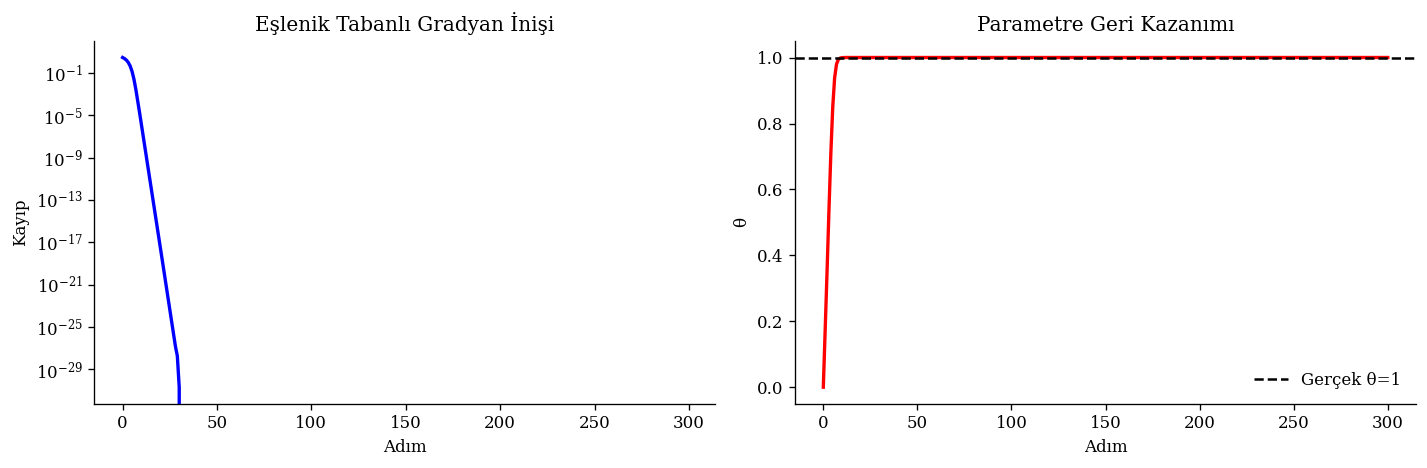

In [2]:
# --- NumPy'da eşlenik yöntem demosu: skaler ADD, açık gradyan ---
# Problem: y' = theta * y, y(0) = 1, L = (y(1) - y_hedef)^2'yi minimize et
# Tam: y(t) = exp(theta * t), grad = 2 * (y(1) - y_hedef) * y(1)

def ileri_euler(theta, t_son=1.0, N=1000):
    h = t_son / N
    y = 1.0
    for _ in range(N):
        y += h * theta * y
    return y

def eslenik_gradyan(theta, y_hedef, t_son=1.0, N=1000):
    """
    Eşlenik yöntem yoluyla dL/dtheta hesaplar.
    İleri: y' = theta*y, y(0)=1
    L = (y(T) - y_hedef)^2
    Eşlenik: ayrık rekürans a_k = a_{k+1}*(1+h*theta)
    Grad:    dL/dtheta = sum_k a_{k+1} * y_{k-1} * h
    """
    h = t_son / N
    # İleri geçiş — yörüngeyi sakla
    # Ayrık güncelleme:  y_{k+1} = y_k * (1 + h*theta)
    y_yor = [1.0]
    y = 1.0
    for _ in range(N):
        y += h * theta * y
        y_yor.append(y)

    L = (y_yor[-1] - y_hedef)**2

    # Geri: AYRIK eşlenik — ileri güncellemeyle tutarlı.
    # y_{k+1} = y_k*(1 + h*theta)'dan:
    #   dy_{k+1}/dy_k   = (1 + h*theta)   -> eşlenik rekürans
    #   dy_{k+1}/dtheta = y_k * h         -> parametre-gradyan terimi
    a = 2 * (y_yor[-1] - y_hedef)        # dL/dy_N
    grad = 0.0
    for k in range(N, 0, -1):
        grad += a * (y_yor[k-1] * h)      # dL/dtheta biriktir
        a = a * (1 + h * theta)            # eşleniği geriye yay

    return L, grad


# Gradyanı sonlu farklarla doğrula
theta_test = 0.5
y_hedef = np.exp(1.0)   # theta=1'de gerçek çözüm

L, grad_esl = eslenik_gradyan(theta_test, y_hedef)

eps = 1e-5
L_arti  = (ileri_euler(theta_test + eps) - y_hedef)**2
L_eksi = (ileri_euler(theta_test - eps) - y_hedef)**2
grad_sf = (L_arti - L_eksi) / (2 * eps)

print(f"Eşlenik gradyan:      {grad_esl:.8f}")
print(f"Sonlu-fark gradyan:   {grad_sf:.8f}")
print(f"Göreli hata:          {abs(grad_esl - grad_sf)/abs(grad_sf):.2e}")

# theta'yı geri kazanmak için basit gradyan inişi
theta = 0.0
lr = 0.05
kayiplar = []
thetalar = [theta]

for adim in range(300):
    L, grad = eslenik_gradyan(theta, y_hedef)
    theta -= lr * grad
    kayiplar.append(L)
    thetalar.append(theta)

print(f"\nOptimize edilen theta = {theta:.6f} (gerçek = 1.0)")

fig, eksenler = plt.subplots(1, 2, figsize=(12, 4))
eksenler[0].semilogy(kayiplar, 'b-', lw=2)
eksenler[0].set_xlabel('Adım'); eksenler[0].set_ylabel('Kayıp')
eksenler[0].set_title('Eşlenik Tabanlı Gradyan İnişi')

eksenler[1].plot(thetalar, 'r-', lw=2)
eksenler[1].axhline(1.0, color='k', ls='--', label='Gerçek θ=1')
eksenler[1].set_xlabel('Adım'); eksenler[1].set_ylabel('θ')
eksenler[1].set_title('Parametre Geri Kazanımı')
eksenler[1].legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 2. PyTorch'ta Sinirsel ADD — Sarmal Yörünge

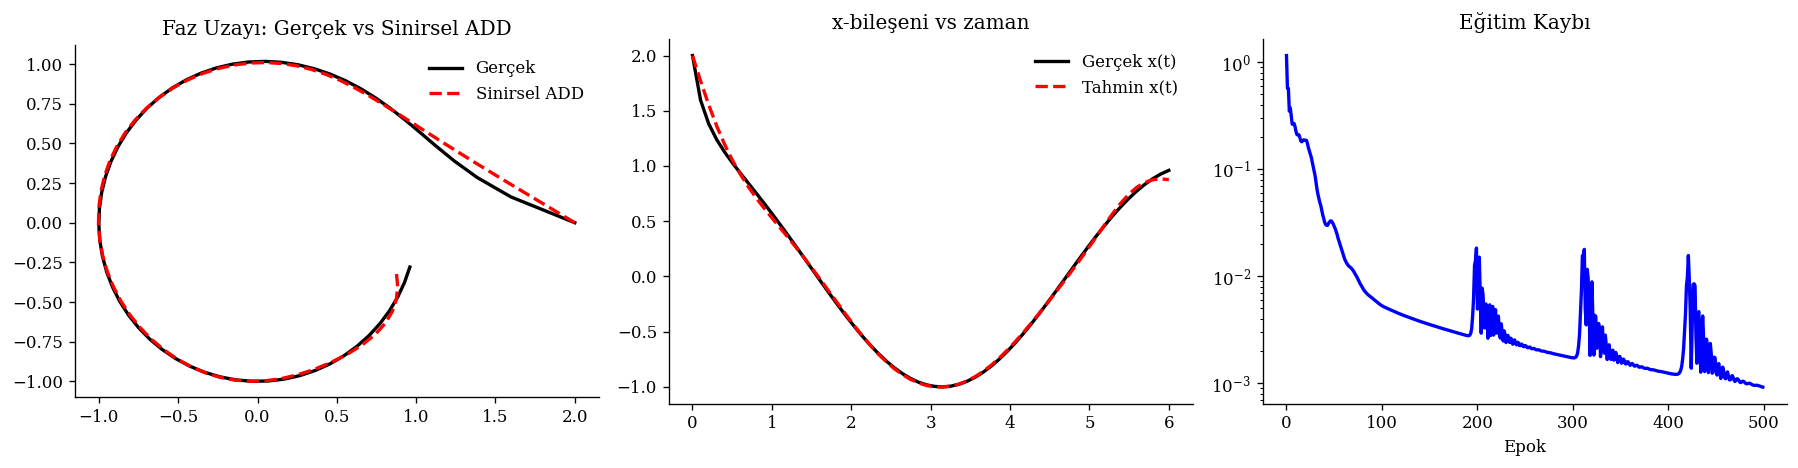

In [3]:
if TORCH_VAR:
    # Eğitim verisi üret: gerçek sarmal dinamik
    # dx/dt = -y + x*(1 - x^2 - y^2)
    # dy/dt =  x + y*(1 - x^2 - y^2)
    def gercek_dinamik(durum, t):
        x, y = durum
        r2 = x**2 + y**2
        return np.array([-y + x*(1 - r2), x + y*(1 - r2)])

    def rk4_np(f, y0, t_dizi):
        durumlar = [y0]
        y = y0.copy()
        for i in range(len(t_dizi)-1):
            h = t_dizi[i+1] - t_dizi[i]
            k1 = f(y, t_dizi[i])
            k2 = f(y + h/2*k1, t_dizi[i]+h/2)
            k3 = f(y + h/2*k2, t_dizi[i]+h/2)
            k4 = f(y + h*k3,   t_dizi[i]+h)
            y = y + h/6*(k1+2*k2+2*k3+k4)
            durumlar.append(y.copy())
        return np.array(durumlar)

    t_egitim = np.linspace(0, 6, 60)
    y0_egitim = np.array([2.0, 0.0])
    yor_gercek = rk4_np(gercek_dinamik, y0_egitim, t_egitim)

    # Sinirsel ADD: dinamiği veriden öğren
    class ADDFonk(nn.Module):
        """ADD'nin öğrenilen sağ tarafı: dh/dt = f_theta(h)"""
        def __init__(self, gizli=32):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(2, gizli),
                nn.Tanh(),
                nn.Linear(gizli, gizli),
                nn.Tanh(),
                nn.Linear(gizli, 2),
            )

        def forward(self, t, y):
            return self.net(y)

    def euler_coz_torch(fonk, y0, t_dizi):
        """PyTorch'ta basit Euler ADD çözücüsü (türevlenebilir)."""
        ys = [y0]
        y = y0
        for i in range(len(t_dizi)-1):
            dt = t_dizi[i+1] - t_dizi[i]
            dy = fonk(t_dizi[i], y)
            y = y + dt * dy
            ys.append(y)
        return torch.stack(ys)

    # Eğitim
    model = ADDFonk(gizli=48)
    optimize_edici = torch.optim.Adam(model.parameters(), lr=0.01)
    t_tensor = torch.tensor(t_egitim, dtype=torch.float32)
    y0_tensor = torch.tensor(y0_egitim, dtype=torch.float32)
    yor_hedef = torch.tensor(yor_gercek, dtype=torch.float32)

    kayiplar_node = []
    for epok in range(500):
        optimize_edici.zero_grad()
        yor_tahmin = euler_coz_torch(model, y0_tensor, t_tensor)
        kayip = torch.mean((yor_tahmin - yor_hedef)**2)
        kayip.backward()
        optimize_edici.step()
        kayiplar_node.append(kayip.item())

    # Çizim
    with torch.no_grad():
        yor_tahmin_np = euler_coz_torch(model, y0_tensor, t_tensor).numpy()

    fig, eksenler = plt.subplots(1, 3, figsize=(15, 4))
    eksenler[0].plot(yor_gercek[:, 0], yor_gercek[:, 1], 'k-', lw=2, label='Gerçek')
    eksenler[0].plot(yor_tahmin_np[:, 0], yor_tahmin_np[:, 1], 'r--', lw=2, label='Sinirsel ADD')
    eksenler[0].set_title('Faz Uzayı: Gerçek vs Sinirsel ADD')
    eksenler[0].legend(frameon=False); eksenler[0].set_aspect('equal')

    eksenler[1].plot(t_egitim, yor_gercek[:, 0], 'k-', lw=2, label='Gerçek x(t)')
    eksenler[1].plot(t_egitim, yor_tahmin_np[:, 0], 'r--', lw=2, label='Tahmin x(t)')
    eksenler[1].set_title('x-bileşeni vs zaman')
    eksenler[1].legend(frameon=False)

    eksenler[2].semilogy(kayiplar_node, 'b-', lw=2)
    eksenler[2].set_title('Eğitim Kaybı'); eksenler[2].set_xlabel('Epok')
    plt.tight_layout(); plt.show()
else:
    print("Bölüm 2 PyTorch gerektirir. Kurulum: pip install torch")

---

## 3. Fizik-Bilgili Sinir Ağları (PINN)

Bir **PINN**, bir sinir ağı $u_\theta(x)$ (veya $u_\theta(x,t)$) eğiterek şunları sağlar:

1. Konum noktalarında **KDD artığı** $\mathcal{L}_{kdd}[u_\theta] = 0$
2. Sınır noktalarında **sınır** / **başlangıç koşulları**

Toplam kayıp:

$$\mathcal{L} = w_1\,\|\mathcal{L}_{kdd}[u_\theta]\|^2 + w_2\,\|u_\theta - g\|^2_{\partial\Omega \cup \{t=0\}}$$

Ağın türevleri **otomatik türev (AD)** ile hesaplanır, bu yüzden ağa (mesh) gerek yoktur.

### 3.1 1B Poisson Denklemi için PINN

$$-u''(x) = f(x) = \pi^2 \sin(\pi x), \quad x \in [0,1], \quad u(0) = u(1) = 0$$

Tam çözüm: $u(x) = \sin(\pi x)$.

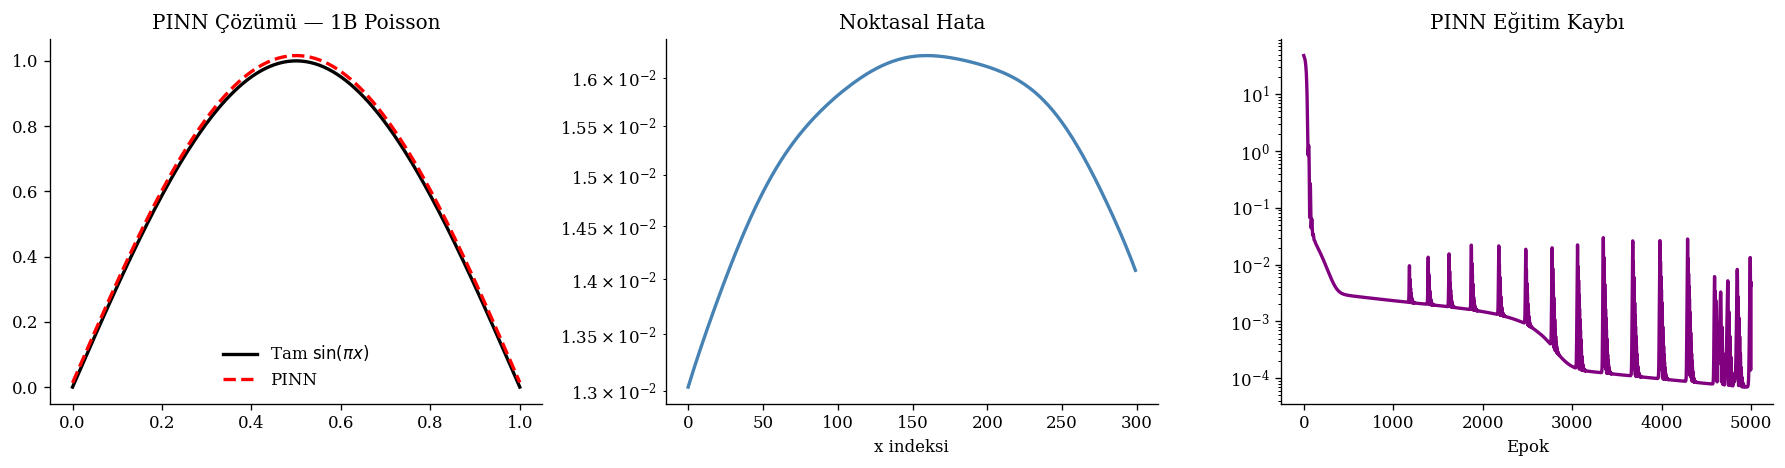

Maks hata: 0.0162


In [4]:
if TORCH_VAR:
    class PINN_Poisson(nn.Module):
        """-u'' = f'yi sağlayan u(x)'i yaklaşık hesaplayan küçük MLP."""
        def __init__(self, gizli=50):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(1, gizli), nn.Tanh(),
                nn.Linear(gizli, gizli), nn.Tanh(),
                nn.Linear(gizli, gizli), nn.Tanh(),
                nn.Linear(gizli, 1),
            )

        def forward(self, x):
            return self.net(x)

    pinn = PINN_Poisson(gizli=50)
    opt = torch.optim.Adam(pinn.parameters(), lr=1e-3)

    # Konum noktaları (iç)
    x_kon = torch.linspace(0, 1, 200).reshape(-1, 1).requires_grad_(True)
    # Sınır noktaları
    x_sk  = torch.tensor([[0.0], [1.0]])
    u_sk  = torch.zeros(2, 1)

    f_kaynak = lambda x: np.pi**2 * torch.sin(np.pi * x)

    kayiplar_pinn = []
    for adim in range(5000):
        opt.zero_grad()

        # KDD artığı: -u'' - f = 0
        u_tahmin = pinn(x_kon)
        u_x = torch.autograd.grad(u_tahmin.sum(), x_kon,
                                   create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x.sum(), x_kon,
                                    create_graph=True)[0]
        kdd_artik = -u_xx - f_kaynak(x_kon)
        kayip_kdd = torch.mean(kdd_artik**2)

        # Sınır koşulu kaybı
        kayip_sk = torch.mean((pinn(x_sk) - u_sk)**2)

        kayip = kayip_kdd + 10 * kayip_sk
        kayip.backward()
        opt.step()
        kayiplar_pinn.append(kayip.item())

    # Değerlendirme
    x_test = torch.linspace(0, 1, 300).reshape(-1, 1)
    with torch.no_grad():
        u_pinn = pinn(x_test).numpy().ravel()
    x_np = x_test.numpy().ravel()
    u_tam_poisson = np.sin(np.pi * x_np)

    fig, eksenler = plt.subplots(1, 3, figsize=(15, 4))
    eksenler[0].plot(x_np, u_tam_poisson, 'k-', lw=2, label='Tam $\\sin(\\pi x)$')
    eksenler[0].plot(x_np, u_pinn, 'r--', lw=2, label='PINN')
    eksenler[0].set_title('PINN Çözümü — 1B Poisson')
    eksenler[0].legend(frameon=False)

    eksenler[1].semilogy(np.abs(u_pinn - u_tam_poisson), 'steelblue', lw=2)
    eksenler[1].set_title('Noktasal Hata')
    eksenler[1].set_xlabel('x indeksi')

    eksenler[2].semilogy(kayiplar_pinn, 'purple', lw=2)
    eksenler[2].set_title('PINN Eğitim Kaybı')
    eksenler[2].set_xlabel('Epok')
    plt.tight_layout(); plt.show()
    print(f"Maks hata: {np.max(np.abs(u_pinn - u_tam_poisson)):.4f}")
else:
    print("Bölüm 3 PyTorch gerektirir.")

---

## 4. PINN'ler vs Klasik Yöntemler — Bir Karşılaştırma

| Yön | Klasik SF/SEY | PINN |
|---|---|---|
| **Ağ (mesh)** | Gerekli | Ağsız |
| **Doğruluk** | Yüksek (kanıtlı yakınsama) | Deneysel, probleme bağlı |
| **Karmaşık geometri** | Zor | Doğal (sadece nokta örnekle) |
| **Eğitim maliyeti** | Yok | Yüksek (optimizasyon döngüsü) |
| **Ters problemler** | Yeniden formülasyon gerektirir | Doğal (ağa parametre ekle) |
| **Dışdeğerleme** | Mümkün değil | Mümkün (uyarılarla) |
| **Garantiler** | Hata sınırları mevcut | Az teorik garanti |

PINN'ler **ters problemlerde** üstündür — KDD'yi yumuşak bir kısıt olarak zorlarken seyrek gözlemlerden parametreleri veya kaynak terimlerini geri kazanır.

---

## 5. Alıştırmalar

1. **(Eşlenik)** Eşlenik yöntemi 2B sistem $\dot{\mathbf{y}} = A\mathbf{y}$'ye genişletin ve $\partial \mathcal{L}/\partial A$ gradyanını sonlu farklarla doğrulayın.

2. **(Sinirsel ADD dışdeğerleme)** Bir Sinirsel ADD'yi $t \in [0, 3]$ üzerinde eğitin ve $t \in [3, 6]$ üzerinde değerlendirin. Dışdeğerleme performansı, aynı veri üzerinde eğitilen standart bir RNN ile nasıl karşılaştırılır?

3. **(Isı denklemi için PINN)** $u_t = u_{xx}$, $u(x,0) = \sin(\pi x)$, $u(0,t) = u(1,t) = 0$ denklemini $[0,1]\times[0,1]$ üzerinde çözmek için bir PINN eğitin. Hatayı ölçmek için analitik çözüm $u = e^{-\pi^2 t}\sin(\pi x)$ kullanın.

4. **(Ters PINN)** Bilinmeyen $\lambda$ ile $-u'' = \lambda\sin(\pi x)$'i sağlayan $u(x)$'in gürültülü gözlemleri verildiğinde, $u$'yu **ve** $\lambda$'yı aynı anda öğrenen bir PINN eğitin. $\lambda$'nın geri kazanımını doğrulayın.

5. **(Konum stratejisi)** Burgers denklemini çözen bir PINN için tekdüze vs uyarlanabilir konum noktası yerleşimini (keskin gradyanlar yakınında yoğunlaşan) karşılaştırın. Hedef bir doğruluğa ulaşmak için gereken nokta sayısı nasıl ölçeklenir?
